# Stroke Prediction using Machine Learning

**Objective:** Predict stroke risk based on patient health data using Random Forest classifier.

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.utils import resample

%matplotlib inline

## 1. Load Data

In [55]:
data = pd.read_csv('healthcare-dataset-stroke-data.csv')
data = data.drop(['id'], axis = 1)
 
print(f"Dataset shape: {data.shape}")
data.head()

Dataset shape: (5110, 11)


,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [56]:
data.describe()

,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


In [57]:
# Coefficient of Variation

numeric_cols = ['age', 'avg_glucose_level', 'bmi']
cv = data[numeric_cols].std() / data[numeric_cols].mean()
print("Coefficient of Variation:")
print(cv.round(2))

Coefficient of Variation:
age                  0.52
avg_glucose_level    0.43
bmi                  0.27
dtype: float64


In [59]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             5110 non-null   str    
 1   age                5110 non-null   float64
 2   hypertension       5110 non-null   int64  
 3   heart_disease      5110 non-null   int64  
 4   ever_married       5110 non-null   str    
 5   work_type          5110 non-null   str    
 6   Residence_type     5110 non-null   str    
 7   avg_glucose_level  5110 non-null   float64
 8   bmi                4909 non-null   float64
 9   smoking_status     5110 non-null   str    
 10  stroke             5110 non-null   int64  
dtypes: float64(3), int64(3), str(5)
memory usage: 439.3 KB


In [85]:
#Distribution % of categorical data

for col in ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']:
    print(data[col].value_counts(normalize = True).round(2), "\n")

gender
Female    0.59
Male      0.41
Other     0.00
Name: proportion, dtype: float64 

ever_married
Yes    0.66
No     0.34
Name: proportion, dtype: float64 

work_type
Private          0.57
Self-employed    0.16
children         0.13
Govt_job         0.13
Never_worked     0.00
Name: proportion, dtype: float64 

Residence_type
Urban    0.51
Rural    0.49
Name: proportion, dtype: float64 

smoking_status
never smoked       0.37
Unknown            0.30
formerly smoked    0.17
smokes             0.15
Name: proportion, dtype: float64 



## 2. Exploratory Data Analysis

Stroke Distribution:
stroke
0    4861
1     249
Name: count, dtype: int64

Imbalance ratio: 19.5:1


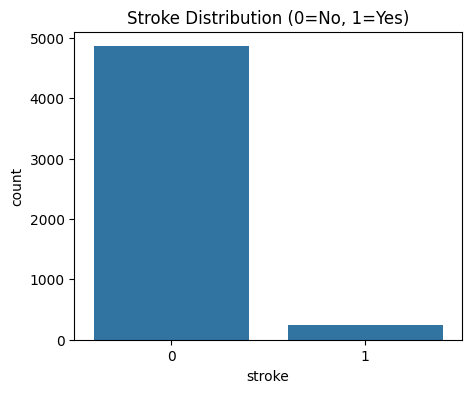

In [84]:
# Target variable distribution
print("Stroke Distribution:")
print(data['stroke'].value_counts())
print(f"\nImbalance ratio: {data['stroke'].value_counts()[0] / data['stroke'].value_counts()[1]:.1f}:1")

plt.figure(figsize = (5,4))
sns.countplot(x = 'stroke', data = data)
plt.title('Stroke Distribution (0=No, 1=Yes)')
plt.show()

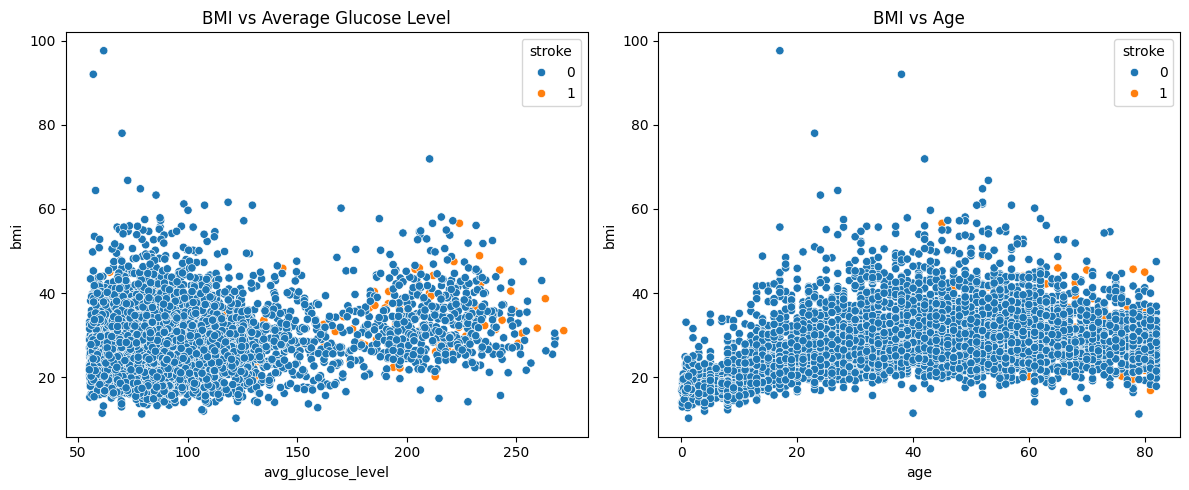

In [43]:
# Stroke Distribution: BMI and Age
plt.figure(figsize = (12,5))

plt.subplot(1,2,1)
plt.title('BMI vs Average Glucose Level')
sns.scatterplot(x = data['avg_glucose_level'], y = data['bmi'], hue = data['stroke'])

plt.subplot(1,2,2)
plt.title('BMI vs Age')
sns.scatterplot(x = data['age'], y = data['bmi'], hue = data['stroke'])

plt.tight_layout()
plt.show()

Missing Values:
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64


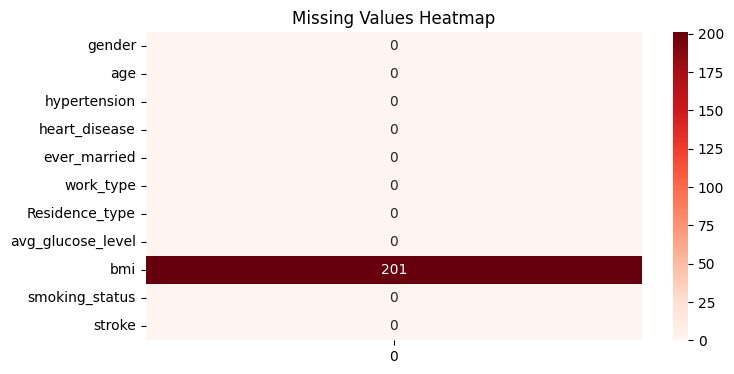

In [44]:
# Missing values
print("Missing Values:")
print(data.isna().sum())

plt.figure(figsize = (8,4))
plt.title('Missing Values Heatmap')
sns.heatmap(data.isna().sum().to_frame(), annot = True, fmt = 'd', cmap = 'Reds')
plt.show()

## 3. Handle Missing Values (BMI)

Using Linear Regression to predict missing BMI values based on gender and age.

In [45]:
# Reload data
data = pd.read_csv('healthcare-dataset-stroke-data.csv')
data = data.drop(['id'], axis=1)

# Separate rows with missing BMI
test_data = data[data['bmi'].isna()].copy()
train_data = data.dropna().copy()

# Encode gender for regression
test_data['gender_encoded'] = test_data['gender'].replace({'Male':0, 'Female':1, 'Other':0})
train_data['gender_encoded'] = train_data['gender'].replace({'Male':0, 'Female':1, 'Other':0})

# Train Linear Regression
X_train_bmi = train_data[['gender_encoded', 'age']]
y_train_bmi = train_data['bmi']

lr = LinearRegression()
lr.fit(X_train_bmi, y_train_bmi)

# Predict missing BMI
X_test_bmi = test_data[['gender_encoded', 'age']]
predicted_bmi = lr.predict(X_test_bmi)

# Fill missing values
data.loc[data['bmi'].isna(), 'bmi'] = predicted_bmi

print(f"Missing values after imputation: {data['bmi'].isna().sum()}")

Missing values after imputation: 0


## 4. Feature Encoding

Convert categorical variables to numeric using LabelEncoder.

In [46]:
# Using LabelEncoder for cleaner encoding
label_encoders = {}
categorical_cols = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']

for col in categorical_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])
    label_encoders[col] = le
    print(f"{col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

data.head()

gender: {'Female': np.int64(0), 'Male': np.int64(1), 'Other': np.int64(2)}
ever_married: {'No': np.int64(0), 'Yes': np.int64(1)}
work_type: {'Govt_job': np.int64(0), 'Never_worked': np.int64(1), 'Private': np.int64(2), 'Self-employed': np.int64(3), 'children': np.int64(4)}
Residence_type: {'Rural': np.int64(0), 'Urban': np.int64(1)}
smoking_status: {'Unknown': np.int64(0), 'formerly smoked': np.int64(1), 'never smoked': np.int64(2), 'smokes': np.int64(3)}


,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,1,67.0,0,1,1,2,1,228.69,36.600000,1,1
1,0,61.0,0,0,1,3,0,202.21,31.101615,2,1
2,1,80.0,0,1,1,2,0,105.92,32.500000,2,1
3,0,49.0,0,0,1,2,1,171.23,34.400000,3,1
4,0,79.0,1,0,1,3,0,174.12,24.000000,2,1


## 5. Train/Test Split

**Important:** Split BEFORE upsampling to prevent data leakage!

In [47]:
# Split data
X = data.drop(['stroke'], axis=1)
y = data['stroke']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size = 0.25, 
    random_state = 42,
    stratify = y  # Maintain class distribution
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"\nTraining class distribution:\n{y_train.value_counts()}")

Training set: 3832 samples
Test set: 1278 samples

Training class distribution:
stroke
0    3645
1     187
Name: count, dtype: int64


## 6. Handle Class Imbalance (Upsampling)

Upsample minority class **only in training data**.

Before upsampling:
  Healthy: 3645
  Stroke: 187

After upsampling:
  Healthy: 3645
  Stroke: 3645


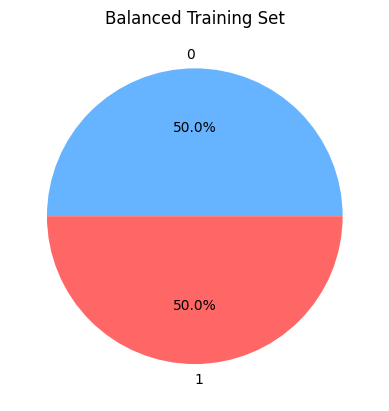

In [48]:
# Combine X_train and y_train for resampling
train_data = pd.concat([X_train, y_train], axis = 1)

# Separate classes
healthy = train_data[train_data['stroke'] == 0]
stroke = train_data[train_data['stroke'] == 1]

print(f"Before upsampling:")
print(f"  Healthy: {len(healthy)}")
print(f"  Stroke: {len(stroke)}")

# Upsample minority class
stroke_upsampled = resample(
    stroke,
    replace = True,
    n_samples = len(healthy),
    random_state = 42
)

# Combine
train_balanced = pd.concat([healthy, stroke_upsampled])

# Separate X and y again
X_train_balanced = train_balanced.drop('stroke', axis=1)
y_train_balanced = train_balanced['stroke']

print(f"\nAfter upsampling:")
print(f"  Healthy: {sum(y_train_balanced == 0)}")
print(f"  Stroke: {sum(y_train_balanced == 1)}")

# Visualize
train_balanced['stroke'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['#66b3ff','#ff6666'])
plt.title('Balanced Training Set')
plt.ylabel('')
plt.show()

## 7. Train Random Forest Model

In [49]:
# Train model on balanced data
rf = RandomForestClassifier(n_estimators = 100, class_weight='balanced', random_state = 42)
rf.fit(X_train_balanced, y_train_balanced)

print("Model trained successfully!")

Model trained successfully!


## 8. Model Evaluation

In [50]:
# Prediction with default threshold (0.5) - baseline
y_pred = rf.predict(X_test)

# Probabillity for every sample to belong in class Stroke
y_pred_proba = rf.predict_proba(X_test)[:, 1]

# Custom threshold (0.3): if stroke probabillity >= 30%, Stroke prediction
# Lower threshold = more detected strokes, lower precision
y_pred_custom = (y_pred_proba >= 0.3).astype(int)

# default threshold vs custom threshold
print("Default threshold (0.5):")
print(classification_report(y_test, y_pred, target_names=['No Stroke', 'Stroke']))

print("Custom threshold (0.3):")
print(classification_report(y_test, y_pred_custom, target_names=['No Stroke', 'Stroke']))


Default threshold (0.5):
              precision    recall  f1-score   support

   No Stroke       0.95      0.99      0.97      1216
      Stroke       0.13      0.03      0.05        62

    accuracy                           0.94      1278
   macro avg       0.54      0.51      0.51      1278
weighted avg       0.91      0.94      0.93      1278

Custom threshold (0.3):
              precision    recall  f1-score   support

   No Stroke       0.96      0.95      0.96      1216
      Stroke       0.20      0.24      0.22        62

    accuracy                           0.92      1278
   macro avg       0.58      0.60      0.59      1278
weighted avg       0.92      0.92      0.92      1278



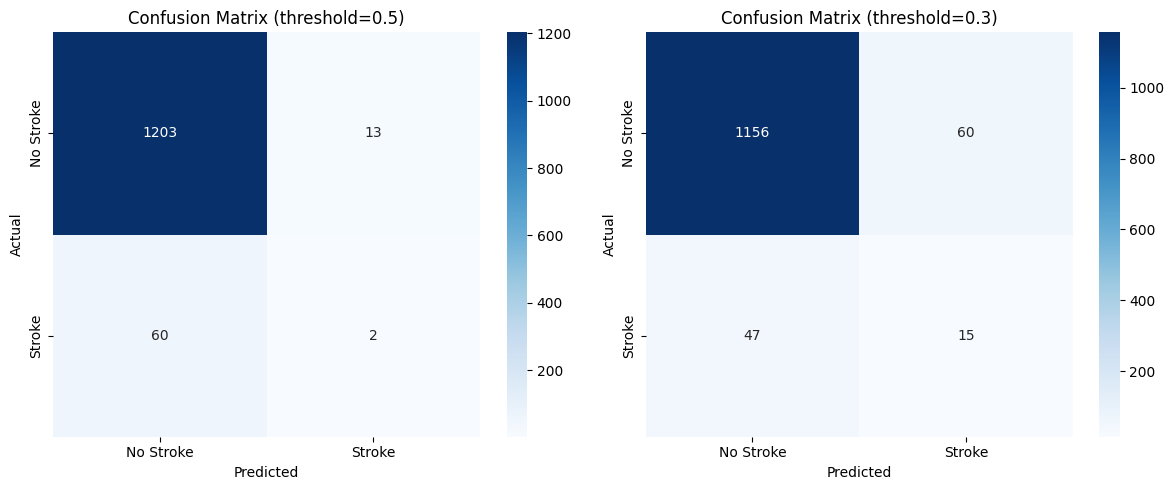

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Default threshold (0.5)
cm1 = confusion_matrix(y_test, y_pred)
sns.heatmap(cm1, annot = True, fmt = 'd', cmap = 'Blues',
            xticklabels = ['No Stroke', 'Stroke'],
            yticklabels = ['No Stroke', 'Stroke'],
            ax = axes[0])
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title('Confusion Matrix (threshold=0.5)')

# Custom threshold (0.3)
cm2 = confusion_matrix(y_test, y_pred_custom)
sns.heatmap(cm2, annot = True, fmt = 'd', cmap = 'Blues',
            xticklabels = ['No Stroke', 'Stroke'],
            yticklabels = ['No Stroke', 'Stroke'],
            ax = axes[1])
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].set_title('Confusion Matrix (threshold=0.3)')

plt.tight_layout()
plt.show()

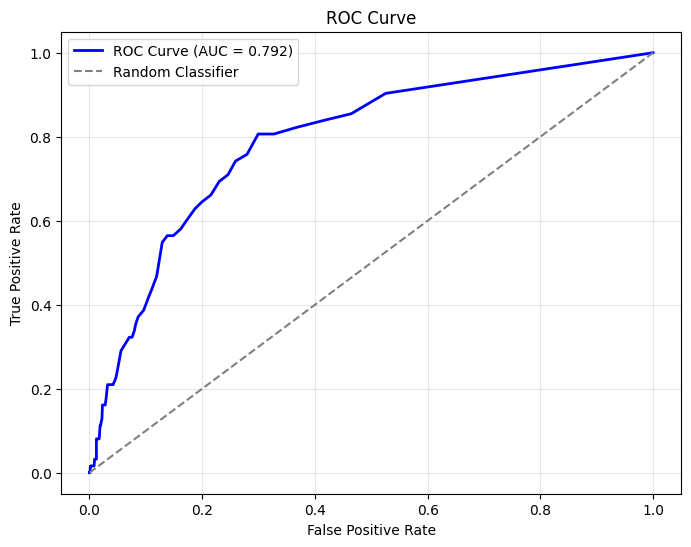

ROC-AUC Score: 0.792


In [52]:
# ROC Curve
roc_auc = roc_auc_score(y_test, y_pred_proba)
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)

plt.figure(figsize = (8,6))
plt.plot(fpr, tpr, color = 'blue', lw = 2, label = f'ROC Curve (AUC = {roc_auc:.3f})')
plt.plot([0,1], [0,1], color = 'gray', linestyle = '--', label = 'Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True, alpha = 0.3)
plt.show()

print(f"ROC-AUC Score: {roc_auc:.3f}")

## 9. Feature Importance

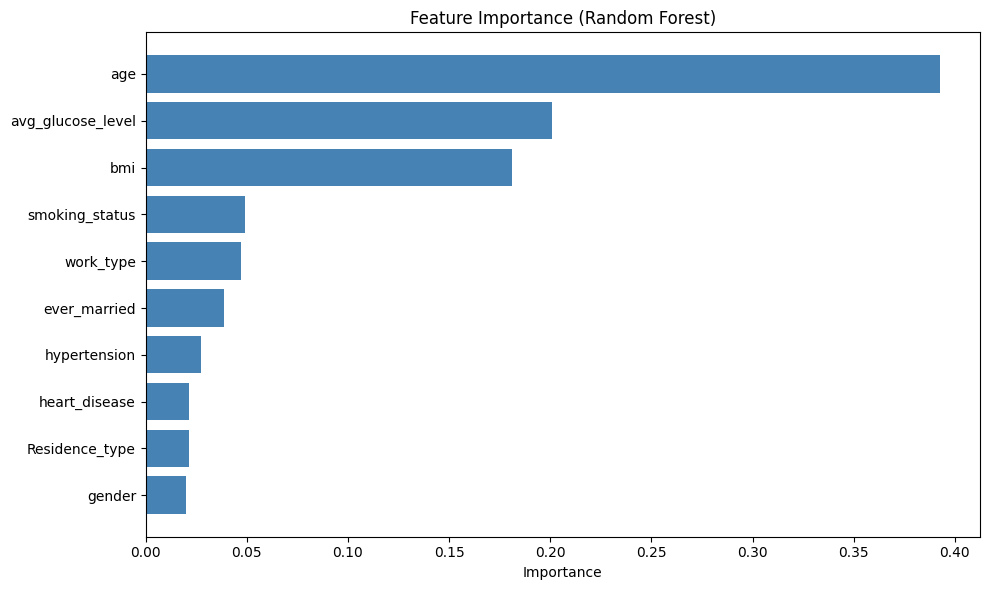


Top 5 most important features:
          feature  importance
              age    0.392820
avg_glucose_level    0.200722
              bmi    0.181294
   smoking_status    0.048930
        work_type    0.046990


In [53]:
# Feature importance from Random Forest
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending = True)

plt.figure(figsize=(10,6))
plt.barh(feature_importance['feature'], feature_importance['importance'], color='steelblue')
plt.xlabel('Importance')
plt.title('Feature Importance (Random Forest)')
plt.tight_layout()
plt.show()

print("\nTop 5 most important features:")
print(feature_importance.tail(5).sort_values('importance', ascending=False).to_string(index=False))


## 10. Summary

**Key Findings:**
- Age is the strongest predictor of stroke risk (importance: 39.2%)
- Average glucose level and BMI follow with 20% and 18.1% respectively
- Lifestyle factors (smoking, work type) show lower but non-negligible importance

**Model Performance:**
- ROC-AUC: 0.792 on unseen test data
- With threshold=0.3 -> Stroke Recall = 0.24
- Trade-off: lower threshold increases false positives but reduces false negatives

**Methodology:**
- Missing BMI values (4%) imputed using Linear Regression on correlated features
- Class imbalance (95/5%) handled via upsampling exclusively on training data to prevent data leakage
- Random Forest (100 trees) with custom threshold tuning for medical use case
